In [2]:
!pip install emnist
!pip install tensorflow
!pip install opencv-contrib-python

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import os, shutil, zipfile, requests

url = "https://github.com/francescopausellii/uniform-coloring-ai/releases/download/v1.0/emnist.zip"
src = "./a.zip"
dst = os.path.expanduser("~/.cache/emnist/emnist.zip")

os.makedirs(os.path.dirname(dst), exist_ok=True)

# download se non esiste o è corrotto
if not os.path.exists(src) or not zipfile.is_zipfile(src):
    print("Scarico EMNIST...")
    with open(src, "wb") as f:
        f.write(requests.get(url).content)

# copia in cache
shutil.copy(src, dst)

print("✅ Pronto:", dst)

Scarico EMNIST...
✅ Pronto: /home/vscode/.cache/emnist/emnist.zip


In [23]:
from emnist import list_datasets
import numpy as np
import pandas as pd
import itertools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import cv2 as cv
from matplotlib import pyplot as plt
list_datasets()


['balanced', 'byclass', 'bymerge', 'digits', 'letters', 'mnist']

Shape of train_images:  (112800, 28, 28)
Image shape: (28, 28)
Max = 255   Min = 0
27


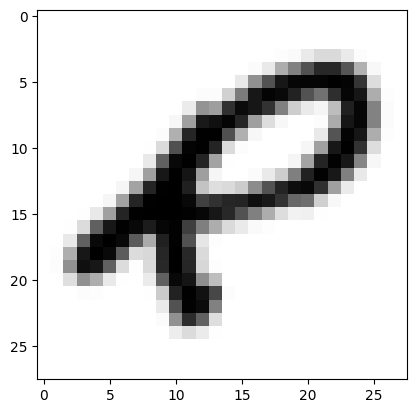

In [24]:
from emnist import extract_training_samples
from emnist import extract_test_samples

x_train, y_train = extract_training_samples('balanced')
x_test, y_test = extract_test_samples('balanced')
# print dataset shape
print("Shape of train_images: ", x_train.shape)
# and the shape of an image
print("Image shape:", x_train[0].shape)

# print the range of the values
print("Max =", np.max(x_train),"  Min =", np.min(x_train))

index = 5434 #exaple

plt.imshow(x_train[index], cmap=plt.cm.binary)
print(y_train[index])

In [35]:
ALL_LABELS = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 
          'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
          'a', 'b', 'd', 'e', 'f', 'g', 'h', 'n', 'q', 'r', 't']

SELECTED_LABELS = ['B', 'G', 'T', 'Y']

def filterDataset(X_data, y_data):
    assert y_data.dtype == np.uint8
    classes = ALL_LABELS
    new_data_size = 0
    for recordIndex in range(0, y_data.shape[0]):
        currentLabel = classes[y_data[recordIndex]]
        if currentLabel in SELECTED_LABELS:
            new_data_size += 1

    new_X_data = np.zeros((new_data_size, 28, 28), dtype = X_data.dtype)
    new_y_data = np.zeros((new_data_size,), dtype = np.uint8)

    new_data_index = 0
    for recordIndex in range(0, y_data.shape[0]):
        currentLabel = classes[y_data[recordIndex]]

        if currentLabel not in SELECTED_LABELS:
            continue
        
        new_X_data[new_data_index] = X_data[recordIndex]
        new_y_data[new_data_index] = SELECTED_LABELS.index(currentLabel)
        new_data_index += 1
    
    assert new_data_index == new_X_data.shape[0]
    return (new_X_data, new_y_data)

In [36]:
(x_train_filter, y_train_filter) = filterDataset(x_train, y_train)
(x_test_filter, y_test_filter) = filterDataset(x_test, y_test)

x_train_filter = x_train_filter / np.max(x_train_filter)
x_test_filter = x_test_filter / np.max(x_test_filter)


x_train_flat = x_train_filter.reshape(len(x_train_filter), (28 * 28))
x_test_flat = x_test_filter.reshape(len(x_test_filter), (28 * 28))

T


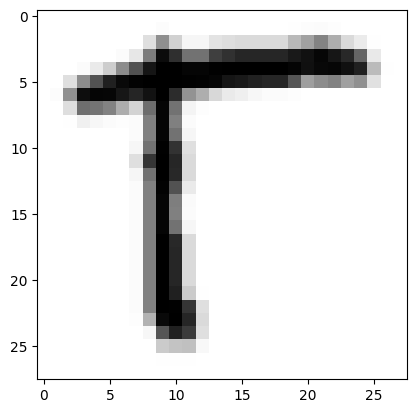

In [37]:
index = 110

plt.imshow(x_train_filter[index], cmap=plt.cm.binary)
print(SELECTED_LABELS[y_train_filter[index]])

In [38]:
from pathlib import Path

modelPath = "models/opt_pretrained_model.keras"

my_file = Path(modelPath)
if my_file.exists():
    model = keras.models.load_model(modelPath)
else:
    model = keras.Sequential([
        layers.Dense(256, input_shape=(784,), activation='relu'),
        layers.Dense(64, activation='relu'),
        
        layers.Dense(len(SELECTED_LABELS), activation='softmax'),
    ])

    #tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs/", histogram_freq=1)

    model.compile(
        optimizer = 'AdamW',
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
    )

    model.fit(x_train_flat, y_train_filter, epochs=7, 
              #callbacks=[tb_callback]
              )

Epoch 1/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9442 - loss: 0.1680
Epoch 2/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9769 - loss: 0.0679
Epoch 3/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9870 - loss: 0.0375
Epoch 4/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9924 - loss: 0.0238
Epoch 5/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9956 - loss: 0.0149
Epoch 6/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9965 - loss: 0.0107
Epoch 7/7
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9952 - loss: 0.0133


In [45]:
# Spazio di ricerca
param_grid = {
    'hidden_layers': [
        [256, 64],
        [256, 128, 64],
        [512, 256, 64, 16],
    ],
    'activations': ['relu', 'tanh', 'sigmoid'],
    'optimizer': ['adam', 'adamw', 'sgd'],
    'dropout_rate': [0.0, 0.2, 0.3],
}

def build_model(hidden_layers, activation, optimizer, dropout_rate):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(len(SELECTED_LABELS), activation='softmax'))
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

results = []

combos = list(itertools.product(
    param_grid['hidden_layers'],
    param_grid['activations'],
    param_grid['optimizer'],
    param_grid['dropout_rate'],
))

for layers_cfg, act, opt, dr in combos:
    model = build_model(layers_cfg, act, opt, dr)
    history = model.fit(
        x_train_flat, y_train_filter,
        epochs=15,
        validation_split=0.1,
        verbose=0
    )
    _, test_acc = model.evaluate(x_test_flat, y_test_filter, verbose=0)
    val_acc = max(history.history['val_accuracy'])
    
    results.append({
        'layers': str(layers_cfg),
        'activation': act,
        'optimizer': opt,
        'dropout': dr,
        'val_accuracy': round(val_acc, 4),
        'test_accuracy': round(test_acc, 4),
        'params': model.count_params(),
    })
    print(f"Done: {layers_cfg} | {act} | {opt} | dr={dr} → test={test_acc:.4f}")

df = pd.DataFrame(results).sort_values('test_accuracy', ascending=False)
print(df.head(10))
df.to_csv('grid_search_results.csv', index=False)

Done: [256, 64] | relu | adam | dr=0.0 → test=0.9411
Done: [256, 64] | relu | adam | dr=0.2 → test=0.9489
Done: [256, 64] | relu | adam | dr=0.3 → test=0.9486
Done: [256, 64] | relu | adamw | dr=0.0 → test=0.9346
Done: [256, 64] | relu | adamw | dr=0.2 → test=0.9475
Done: [256, 64] | relu | adamw | dr=0.3 → test=0.9389
Done: [256, 64] | relu | sgd | dr=0.0 → test=0.9264
Done: [256, 64] | relu | sgd | dr=0.2 → test=0.9239
Done: [256, 64] | relu | sgd | dr=0.3 → test=0.9221
Done: [256, 64] | tanh | adam | dr=0.0 → test=0.9407
Done: [256, 64] | tanh | adam | dr=0.2 → test=0.9436
Done: [256, 64] | tanh | adam | dr=0.3 → test=0.9418
Done: [256, 64] | tanh | adamw | dr=0.0 → test=0.9361
Done: [256, 64] | tanh | adamw | dr=0.2 → test=0.9318
Done: [256, 64] | tanh | adamw | dr=0.3 → test=0.9414
Done: [256, 64] | tanh | sgd | dr=0.0 → test=0.9096
Done: [256, 64] | tanh | sgd | dr=0.2 → test=0.9007
Done: [256, 64] | tanh | sgd | dr=0.3 → test=0.8964
Done: [256, 64] | sigmoid | adam | dr=0.0 → te

In [46]:
# Miglior configurazione
print(df.iloc[0])

# Effetto dell'activation function (media per gruppo)
print(df.groupby('activation')['test_accuracy'].mean().sort_values(ascending=False))
print(df.groupby('optimizer')['test_accuracy'].mean().sort_values(ascending=False))
print(df.groupby('dropout')['test_accuracy'].mean().sort_values(ascending=False))

layers           [256, 64]
activation            relu
optimizer             adam
dropout                0.2
val_accuracy        0.9524
test_accuracy       0.9489
params              217863
Name: 1, dtype: object
activation
relu       0.937896
tanh       0.926374
sigmoid    0.806344
Name: test_accuracy, dtype: float64
optimizer
adam     0.940870
adamw    0.939956
sgd      0.789789
Name: test_accuracy, dtype: float64
dropout
0.0    0.892978
0.2    0.892293
0.3    0.885344
Name: test_accuracy, dtype: float64


In [47]:
import keras_tuner as kt

def model_builder(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))
    for i in range(hp.Int('num_layers', 1, 4)):
        model.add(layers.Dense(
            units=hp.Choice(f'units_{i}', [32, 64, 128, 256, 512]),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ))
    model.add(layers.Dense(len(SELECTED_LABELS), activation='softmax'))
    model.compile(
        optimizer=hp.Choice('optimizer', ['adam', 'adamw']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

tuner = kt.RandomSearch(model_builder, objective='val_accuracy', max_trials=30)
tuner.search(x_train_flat, y_train_filter, epochs=15, validation_split=0.1)
print(tuner.results_summary())

Trial 30 Complete [00h 00m 16s]
val_accuracy: 0.9488095045089722

Best val_accuracy So Far: 0.9541666507720947
Total elapsed time: 00h 08m 44s
Results summary
Results in .\untitled_project
Showing 10 best trials
Objective(name="val_accuracy", direction="max")

Trial 27 summary
Hyperparameters:
num_layers: 2
units_0: 512
activation: relu
optimizer: adam
units_1: 512
units_2: 256
units_3: 64
Score: 0.9541666507720947

Trial 01 summary
Hyperparameters:
num_layers: 2
units_0: 512
activation: relu
optimizer: adamw
units_1: 32
units_2: 128
units_3: 512
Score: 0.9511904716491699

Trial 04 summary
Hyperparameters:
num_layers: 2
units_0: 512
activation: tanh
optimizer: adam
units_1: 32
units_2: 256
units_3: 32
Score: 0.9511904716491699

Trial 03 summary
Hyperparameters:
num_layers: 3
units_0: 256
activation: relu
optimizer: adamw
units_1: 256
units_2: 256
units_3: 64
Score: 0.9505952596664429

Trial 12 summary
Hyperparameters:
num_layers: 1
units_0: 256
activation: tanh
optimizer: adamw
units_1

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs/

In [39]:
result = model.evaluate(x_test_flat, y_test_filter)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9731 - loss: 0.1343


In [36]:
model.save(modelPath)

In [32]:
y_predicted = model.predict(x_test_flat)


88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [33]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]

In [ ]:
cm = tf.math.confusion_matrix(labels=y_test_filter, predictions=y_predicted_labels)
cmfarlo

<tf.Tensor: shape=(7, 7), dtype=int32, numpy=
array([[386,   2,   1,   5,   6,   0,   0],
       [  9, 383,   1,   1,   2,   0,   4],
       [  0,   0, 382,   2,  10,   0,   6],
       [ 10,   5,   0, 373,  12,   0,   0],
       [  8,   1,  15,  10, 364,   0,   2],
       [  0,   0,   3,   0,   3, 378,  16],
       [  2,   4,   0,   0,   2,  21, 371]])>

In [40]:
image  = cv.imread("fotos/1776851067333.png")
original = image.copy()
ROI_number = 0
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

cv.imwrite('gray.png', gray)

blur = cv.GaussianBlur(gray, (5,5), 0)

cv.imwrite('blur.png', blur)

thresh = cv.adaptiveThreshold(blur, 255, 1, 1, 11, 2)


cv.imwrite('tresh.png', thresh)

max_area = 0
c = 0
contours, _ = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

for i in contours:
        area = cv.contourArea(i)
        if area > 70*60:
                if area > max_area:
                    max_area = area
                    best_cnt = i
                    image = cv.drawContours(image, contours, c, (0, 255, 0), 3)
        c+=1


mask = np.zeros((gray.shape),np.uint8)
cv.drawContours(mask,[best_cnt],0,255,-1)
cv.drawContours(mask,[best_cnt],0,0,2)


out = np.zeros_like(gray)
out[mask == 255] = gray[mask == 255]

c = 0
n = 0

yt = 0
l = []
for i in contours:
    area = cv.contourArea(i)
    if area > 70*60:

        x,y,w,h = cv.boundingRect(i)
        cv.rectangle(image, (x, y), (x + w, y + h), (36,255,12), 2)
        ROI = original[y:y+h, x:x+w]
        #print(ROI_number," x: ", x, " y: ", y)
        if ROI_number != 0:
            if yt == y:
                ROI = ROI[3:67,3:67] #rimuovi bordo
                cv.imwrite('ROI_{}.png'.format(ROI_number), ROI)
                n+=1
            else:
                ROI = ROI[3:67,3:67] #rimuovi bordo
                yt = y
                cv.imwrite('ROI_{}.png'.format(ROI_number), ROI)
                n = 1


        ROI_number += 1        
        

        cv.drawContours(image, contours, c, (0, 255, 0), 3)
    c+=1

In [41]:
l=[]
for i in range(1, ROI_number):
  im = cv.imread("ROI_"+str(i)+".png")
  im = cv.bitwise_not(im)
  im = cv.cvtColor(im, cv.COLOR_BGR2GRAY)
  (thresh, im) = cv.threshold(im, 127, 255, cv.THRESH_BINARY)
  
  #im = im[3:67,3:67]  #rimuovi bordo

  im = cv.resize(im, dsize=(28, 28), interpolation=cv.INTER_LINEAR)


  im = np.reshape(im, -1)
  im = im.astype("float32")/255
  im = tf.expand_dims(im, 0)

  prediction = model.predict(im)
  max = np.where(prediction == np.amax(prediction))
  l.append(int(max[1]))



if n < len(l):
    nrow= len(l)/n
else:
    nrow=n/len(l)

nrow = int(nrow)

mat = np.array(list(reversed(l)))

grid=mat.reshape(nrow, n)
show=np.copy(grid)
show = np.where(show==0,'B',show)
show = np.where(show=='1','G',show)
show = np.where(show=='2','T',show)
show = np.where(show=='3','Y',show)
print(show)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

/tmp/ipykernel_3127/3688314940.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  l.append(int(max[1]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[['G']
 ['G']
 ['Y']
 ['Y']
 ['G']
 ['Y']
 ['B']
 ['B']
 ['G']]


In [4]:


img = cv.imread('fototest/imgG.jpeg')

def rescaleFrame(frame, dimensions=None):
    if(dimensions != None):
        return cv.resize(frame, dimensions, interpolation=cv.INTER_AREA)
    
    scale = 0.60
    width = int(frame.shape[1] * scale)
    height = int(frame.shape[0] * scale)

    dimensions = (width, height)
    return cv.resize(frame, dimensions, interpolation=cv.INTER_AREA)

#cv.imshow('Test', rescaleFrame(img)) 

rescaledImg = rescaleFrame(img, (300, 300))

blank = np.zeros(rescaledImg.shape, dtype='uint8')

gray = cv.cvtColor(rescaledImg, cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray, 127, 255, cv.THRESH_BINARY)
cv.imshow("Thresh", thresh)

contours, hierarchies = cv.findContours(thresh, cv.RETR_LIST, cv.CHAIN_APPROX_SIMPLE)
print(len(contours))

cv.drawContours(blank, contours, -1, (0, 0, 255), 1)
cv.imshow("Contours Drawn", blank)
#print(hierarchies)
#print(contours)

cv.waitKey(0)

254


-1